# MedGuard: Multi-Task Mammography AI

**Dataset:** CBIS-DDSM Breast Cancer Image Dataset  
**Main task:** Benign vs Malignant mammography analysis

This notebook builds one complete medical-imaging pipeline with three connected outputs:

1. **Classification** - predicts whether the lesion is **Benign** or **Malignant**.
2. **Segmentation** - predicts the lesion mask.
3. **Explainable AI (XAI)** - uses **Grad-CAM++** to show where the classifier focused.

The core idea is create one aligned lesion-crop dataset and use it for all three tasks. Each sample contains a cropped mammogram image and the matching cropped ROI mask.

This alignment makes the workflow easier to evaluate because the classifier, segmenter, and XAI method all work on the same lesion region.

The most important metrics are:

- **Classification:** AUC, PR-AUC, Macro F1, Balanced Accuracy, Malignant Recall, False Negatives.
- **Segmentation:** Dice and IoU.
- **XAI:** CAM-IoU between Grad-CAM++ heatmap and the ground-truth lesion mask.


## 1. Install and Imports

Installs the required libraries and packages


In [1]:
!pip install -q timm kagglehub segmentation-models-pytorch albumentations
# If a version conflict appears after install: Runtime > Restart session, then run from here.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.7 MB/s eta 0:00:00


In [2]:
import kagglehub

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os, cv2, json, math, random, warnings, zipfile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, f1_score, accuracy_score,
                             balanced_accuracy_score)

warnings.filterwarnings("ignore")

## 2. Configuration

In [3]:
SEED = 42
IMAGE_SIZE = 384
NUM_CLASSES = 2
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# models
CLS_ENCODER = "tf_efficientnetv2_s.in21k_ft_in1k"

SEG_ENCODER = "timm-efficientnet-b3"
SEG_ENCODER_WEIGHTS = "noisy-student"

# These crops use the ground-truth ROI mask to locate the lesion.
CONTEXT = 0.60
CACHE_DIR = f"/content/medguard_crops_{IMAGE_SIZE}"

# classification training configuration
CLS_BATCH = 8
CLS_PHASE1_EPOCHS = 3
CLS_PHASE2_EPOCHS = 18
CLS_PATIENCE = 5
CLS_MIN_DELTA = 1e-3

CLS_HEAD_LR = 8e-4
CLS_BACKBONE_LR_DEEP = 3e-5
CLS_HEAD_FINE_LR = 8e-5
CLS_WEIGHT_DECAY = 2e-3
CLS_DROPOUT = 0.40
LABEL_SMOOTHING = 0.03
CLS_TRAIN_LAST_RATIO = 0.35
MAX_GRAD_NORM = 1.0

# FN reduction controls
MALIGNANT_LOSS_MULTIPLIER = 2.0
TARGET_RECALL = 0.80
MIN_SPECIFICITY_FOR_THRESHOLD = 0.45
FN_COST = 10_000
FP_COST = 100

# Segmentation training configuration
SEG_BATCH = 8
SEG_EPOCHS = 35
SEG_PATIENCE = 8
SEG_ENC_LR = 1e-4
SEG_DEC_LR = 1e-3

label_names = ["Benign", "Malignant"]
label_map = {"BENIGN_WITHOUT_CALLBACK": 0, "BENIGN": 0, "MALIGNANT": 1}

CLS_CKPT = "MedGuard_classifier_v1.pth"
SEG_CKPT = "MedGuard_segmenter_v1.pth"


def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

print("Device:", DEVICE)
print("Image size:", IMAGE_SIZE)
print("Classifier encoder:", CLS_ENCODER)
print("Classifier fine-tune ratio:", CLS_TRAIN_LAST_RATIO)
print("Classifier dropout:", CLS_DROPOUT, "| label smoothing:", LABEL_SMOOTHING)
print("Malignant loss multiplier:", MALIGNANT_LOSS_MULTIPLIER)
print("Target malignant recall:", TARGET_RECALL)
if DEVICE.type != "cuda":
    print("WARNING: enable GPU -> Runtime > Change runtime type > T4 GPU")

Device: cuda
Image size: 384
Classifier encoder: tf_efficientnetv2_s.in21k_ft_in1k
Classifier fine-tune ratio: 0.35
Classifier dropout: 0.4 | label smoothing: 0.03
Malignant loss multiplier: 2.0
Target malignant recall: 0.8


## 3. Dataset Preparation


In [4]:
path = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")

print("Dataset path:", path)
CSV_DIR  = os.path.join(path, "csv")
JPEG_DIR = os.path.join(path, "jpeg")

Using Colab cache for faster access to the 'cbis-ddsm-breast-cancer-image-dataset' dataset.
Dataset path: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset


In [5]:
mass_train = pd.read_csv(os.path.join(CSV_DIR, "mass_case_description_train_set.csv"))
mass_test  = pd.read_csv(os.path.join(CSV_DIR, "mass_case_description_test_set.csv"))
calc_train = pd.read_csv(os.path.join(CSV_DIR, "calc_case_description_train_set.csv"))
calc_test  = pd.read_csv(os.path.join(CSV_DIR, "calc_case_description_test_set.csv"))
dicom_info = pd.read_csv(os.path.join(CSV_DIR, "dicom_info.csv"))

mass_train["abnormality_source"] = "mass"; mass_test["abnormality_source"] = "mass"
calc_train["abnormality_source"] = "calcification"; calc_test["abnormality_source"] = "calcification"

# Keep the full-image and ROI-mask path columns (needed for aligned crops)
keep_cols = ["patient_id", "pathology", "abnormality_source", "image view",
             "image file path", "cropped image file path", "ROI mask file path"]

def align_columns(df, cols):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            out[c] = np.nan
    return out[cols]

all_raw = pd.concat([align_columns(d, keep_cols) for d in
                     [mass_train, calc_train, mass_test, calc_test]], ignore_index=True)
all_raw = all_raw[all_raw["pathology"].isin(label_map)].reset_index(drop=True)
all_raw["label"] = all_raw["pathology"].map(label_map).astype(int)
all_raw["label_name"] = all_raw["label"].map({0: "Benign", 1: "Malignant"})
print("Raw records:", len(all_raw))
print("Labels:", all_raw["label"].value_counts().sort_index().to_dict())

Raw records: 3568
Labels: {0: 2111, 1: 1457}


## 4. Resolve Image and Mask Paths

CBIS-DDSM stores images using DICOM series information. This section maps each record to:

- the full mammogram image
- the ROI mask image

In [6]:
def build_uid_map(dinfo, series_desc):
    sub = dinfo[dinfo["SeriesDescription"] == series_desc].copy()
    sub["series_uid"] = sub["SeriesInstanceUID"].astype(str)
    sub["jpg_filename"] = sub["image_path"].apply(lambda x: os.path.basename(str(x)))
    return dict(zip(sub["series_uid"], sub["jpg_filename"]))

full_uid_map = build_uid_map(dicom_info, "full mammogram images")
mask_uid_map = build_uid_map(dicom_info, "ROI mask images")
print("full map:", len(full_uid_map), "| mask map:", len(mask_uid_map))

def resolve(path_str, uid_map):
    if pd.isna(path_str):
        return None
    parts = str(path_str).replace("\\", "/").split("/")
    uids = [p for p in parts if p.startswith("1.3.6")]
    for uid in uids:
        if uid in uid_map:
            return os.path.join(JPEG_DIR, uid, uid_map[uid])
    return None

all_raw["full_path"] = all_raw["image file path"].apply(lambda p: resolve(p, full_uid_map))
all_raw["mask_path"] = all_raw["ROI mask file path"].apply(lambda p: resolve(p, mask_uid_map))
resolved = all_raw.dropna(subset=["full_path", "mask_path"]).reset_index(drop=True)
print("Records with both full image + mask resolved:", len(resolved), "/", len(all_raw))

full map: 2857 | mask map: 3247
Records with both full image + mask resolved: 3241 / 3568


## 5. Data preprocessing

1. Loads the full mammogram.
2. Loads the ground-truth ROI mask.
3. Finds the lesion bounding box from the mask.
4. Expands the box to include surrounding tissue.
5. Crops both image and mask using the same coordinates.
6. Normalizes the mammogram crop.
7. Resizes and pads the crop to a fixed square size.
8. Saves the cropped image and cropped mask as PNG files.

In [7]:
def normalize_uint8(img, lo_pct=0.5, hi_pct=99.7):
    img = img.astype(np.float32)
    lo, hi = np.percentile(img, (lo_pct, hi_pct))
    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo + 1e-6)
    return (img * 255).astype(np.uint8)

def largest_component_bbox(mask_bin):
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(mask_bin.astype(np.uint8), connectivity=8)
    if n <= 1:
        return None
    idx = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    x = stats[idx, cv2.CC_STAT_LEFT]; y = stats[idx, cv2.CC_STAT_TOP]
    w = stats[idx, cv2.CC_STAT_WIDTH]; h = stats[idx, cv2.CC_STAT_HEIGHT]
    return x, y, w, h

def expand_bbox(x, y, w, h, W, H, ctx):
    cx, cy = x + w / 2.0, y + h / 2.0
    nw, nh = w * (1 + ctx), h * (1 + ctx)
    x1 = int(max(0, cx - nw / 2)); y1 = int(max(0, cy - nh / 2))
    x2 = int(min(W, cx + nw / 2)); y2 = int(min(H, cy + nh / 2))
    return x1, y1, x2, y2

def resize_pad(img, size, is_mask=False):
    h, w = img.shape[:2]
    scale = size / max(h, w)
    nh, nw = max(1, int(h * scale)), max(1, int(w * scale))
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    r = cv2.resize(img, (nw, nh), interpolation=interp)
    canvas = np.zeros((size, size), dtype=img.dtype)
    y0, x0 = (size - nh) // 2, (size - nw) // 2
    canvas[y0:y0 + nh, x0:x0 + nw] = r
    return canvas

os.makedirs(CACHE_DIR, exist_ok=True)
img_paths, mask_paths, keep = [], [], []

for i, row in tqdm(resolved.iterrows(), total=len(resolved), desc="caching crops"):
    fp, mp = row["full_path"], row["mask_path"]
    img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    if img is None or msk is None:
        img_paths.append(None); mask_paths.append(None); keep.append(False); continue
    if msk.shape != img.shape:
        msk = cv2.resize(msk, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    thr = 0.5 * msk.max() if msk.max() > 0 else 0
    mb = (msk > thr).astype(np.uint8)
    mb = cv2.morphologyEx(mb, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    bb = largest_component_bbox(mb)
    if bb is None:
        img_paths.append(None); mask_paths.append(None); keep.append(False); continue
    x, y, w, h = bb
    x1, y1, x2, y2 = expand_bbox(x, y, w, h, img.shape[1], img.shape[0], CONTEXT)
    img_c = normalize_uint8(img[y1:y2, x1:x2])
    msk_c = (mb[y1:y2, x1:x2] * 255).astype(np.uint8)
    img_c = resize_pad(img_c, IMAGE_SIZE, is_mask=False)
    msk_c = (resize_pad(msk_c, IMAGE_SIZE, is_mask=True) > 127).astype(np.uint8) * 255
    ip = os.path.join(CACHE_DIR, f"img_{i}.png")
    kp = os.path.join(CACHE_DIR, f"msk_{i}.png")
    cv2.imwrite(ip, img_c); cv2.imwrite(kp, msk_c)
    img_paths.append(ip); mask_paths.append(kp); keep.append(True)

resolved["img_crop_path"] = img_paths
resolved["mask_crop_path"] = mask_paths
data_df = resolved[pd.Series(keep, index=resolved.index)].reset_index(drop=True)
print("\nUsable aligned samples:", len(data_df), "/", len(resolved))
print("Labels:", data_df["label"].value_counts().sort_index().to_dict())
assert len(data_df) > 2000, "Too few samples cached - check path resolution before continuing."


caching crops:   0%|          | 0/3241 [00:00<?, ?it/s]


Usable aligned samples: 3241 / 3241
Labels: {0: 1913, 1: 1328}


The green contour is the ground-truth ROI mask.


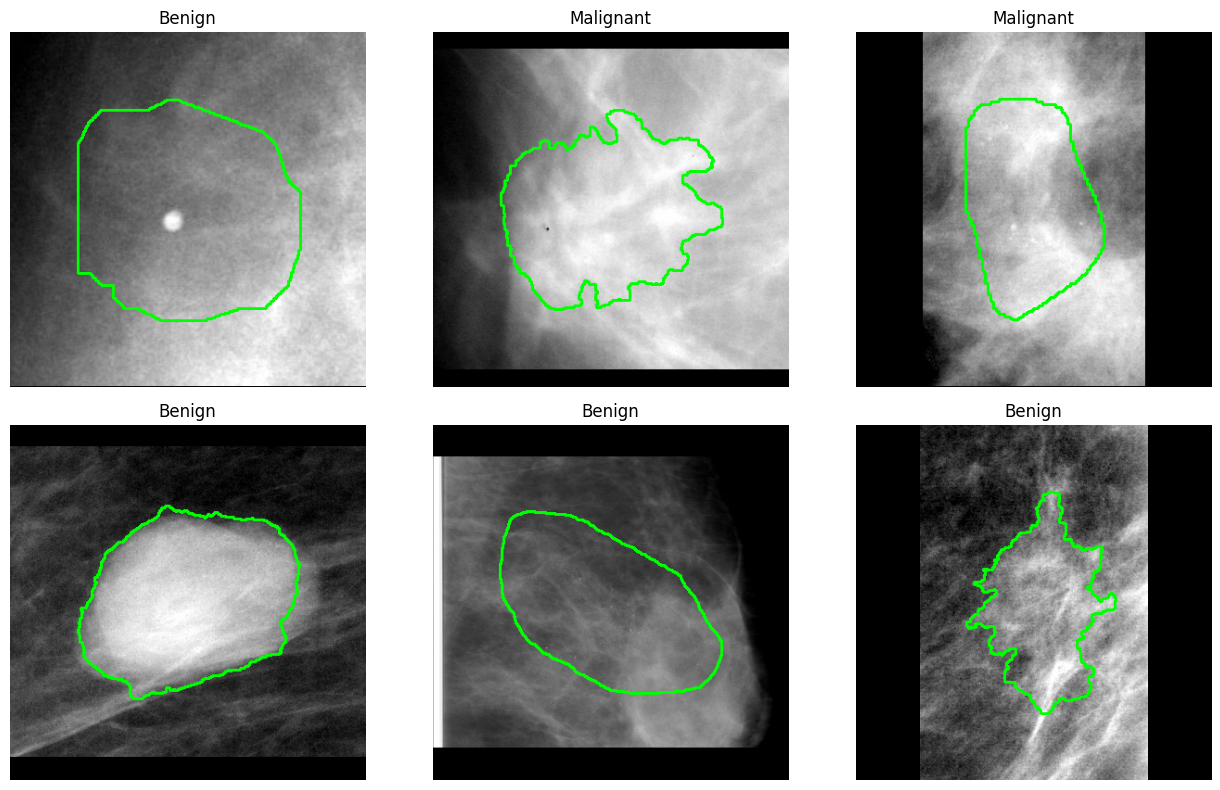

In [8]:
samples = data_df.sample(6, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (_, r) in zip(axes.ravel(), samples.iterrows()):
    img = cv2.imread(r["img_crop_path"], cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(r["mask_crop_path"], cv2.IMREAD_GRAYSCALE)
    rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    cnts, _ = cv2.findContours((msk > 127).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(rgb, cnts, -1, (0, 255, 0), 2)
    ax.imshow(rgb); ax.set_title(r["label_name"]); ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Data split 70%-15%-15%

The data is split into train, validation, and test sets by `patient_id`, to avoid data leakage.


In [9]:
patient_df = data_df.groupby("patient_id").agg(
    patient_label=("label", lambda x: int(x.mode()[0]))).reset_index()

sgkf1 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
tv_idx, te_idx = next(sgkf1.split(patient_df, patient_df["patient_label"], patient_df["patient_id"]))
tv_patients = set(patient_df.iloc[tv_idx]["patient_id"])
te_patients = set(patient_df.iloc[te_idx]["patient_id"])

tv_df = data_df[data_df["patient_id"].isin(tv_patients)].reset_index(drop=True)
test_df = data_df[data_df["patient_id"].isin(te_patients)].reset_index(drop=True)

p_tv = tv_df.groupby("patient_id").agg(patient_label=("label", lambda x: int(x.mode()[0]))).reset_index()
sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf2.split(p_tv, p_tv["patient_label"], p_tv["patient_id"]))
tr_patients = set(p_tv.iloc[tr_idx]["patient_id"])
va_patients = set(p_tv.iloc[va_idx]["patient_id"])

train_df = tv_df[tv_df["patient_id"].isin(tr_patients)].reset_index(drop=True)
val_df   = tv_df[tv_df["patient_id"].isin(va_patients)].reset_index(drop=True)

print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val:  ", len(val_df),   val_df["label"].value_counts().sort_index().to_dict())
print("Test: ", len(test_df),  test_df["label"].value_counts().sort_index().to_dict())

a, b, c = set(train_df.patient_id), set(val_df.patient_id), set(test_df.patient_id)
assert len(a & b) == 0 and len(a & c) == 0 and len(b & c) == 0
print("No patient-level leakage.")

Train: 2074 {0: 1205, 1: 869}
Val:   487 {0: 313, 1: 174}
Test:  680 {0: 395, 1: 285}
No patient-level leakage.


## 7. Transforms and DataLoaders



In [10]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


def make_coarse_dropout(p=0.15):
    """Albumentations changed CoarseDropout argument names across versions."""
    try:
        return A.CoarseDropout(
            num_holes_range=(1, 3),
            hole_height_range=(0.03, 0.08),
            hole_width_range=(0.03, 0.08),
            fill=0,
            p=p,
        )
    except TypeError:
        return A.CoarseDropout(
            min_holes=1,
            max_holes=3,
            max_height=max(8, IMAGE_SIZE // 12),
            max_width=max(8, IMAGE_SIZE // 12),
            fill_value=0,
            p=p,
        )

cls_train_tf = A.Compose([
    A.CLAHE(clip_limit=2.0, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, border_mode=cv2.BORDER_CONSTANT, p=0.6),
    A.Affine(translate_percent=0.04, scale=(0.93, 1.07), shear=3, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.30),
    A.GaussNoise(p=0.15),
    make_coarse_dropout(p=0.15),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

seg_train_tf = A.Compose([
    A.CLAHE(clip_limit=2.0, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=8, border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.Affine(translate_percent=0.03, scale=(0.95, 1.05), shear=2, p=0.4),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

eval_tf = A.Compose([
    A.CLAHE(clip_limit=2.0, p=1.0),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])


def load_rgb(p):
    g = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    return cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)


class ClsDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        out = self.tf(image=load_rgb(r["img_crop_path"]))
        return out["image"], int(r["label"])


class SegDataset(Dataset):
    def __init__(self, df, tf):
        self.df = df.reset_index(drop=True); self.tf = tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = load_rgb(r["img_crop_path"])
        msk = (cv2.imread(r["mask_crop_path"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.float32)
        out = self.tf(image=img, mask=msk)
        return out["image"], out["mask"].unsqueeze(0).float()

loader_kw = dict(
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

cls_train_loader = DataLoader(ClsDataset(train_df, cls_train_tf), batch_size=CLS_BATCH, shuffle=True, drop_last=True, **loader_kw)
cls_val_loader   = DataLoader(ClsDataset(val_df,   eval_tf),       batch_size=CLS_BATCH, shuffle=False, **loader_kw)
cls_test_loader  = DataLoader(ClsDataset(test_df,  eval_tf),       batch_size=CLS_BATCH, shuffle=False, **loader_kw)

seg_train_loader = DataLoader(SegDataset(train_df, seg_train_tf), batch_size=SEG_BATCH, shuffle=True, drop_last=True, **loader_kw)
seg_val_loader   = DataLoader(SegDataset(val_df,   eval_tf),      batch_size=SEG_BATCH, shuffle=False, **loader_kw)
seg_test_loader  = DataLoader(SegDataset(test_df,  eval_tf),      batch_size=SEG_BATCH, shuffle=False, **loader_kw)

xb, yb = next(iter(cls_train_loader)); print("cls batch:", xb.shape, yb.shape)
xs, ys = next(iter(seg_train_loader)); print("seg batch:", xs.shape, ys.shape)


cls batch: torch.Size([8, 3, 384, 384]) torch.Size([8])
seg batch: torch.Size([8, 3, 384, 384]) torch.Size([8, 1, 384, 384])


## 8. Training



### 8.1 Classification Model

In [11]:
class ClsModel(nn.Module):
    def __init__(self, name, num_classes=2, drop=0.40):
        super().__init__()
        self.backbone = timm.create_model(name, pretrained=True, num_classes=0, global_pool="avg")
        f = self.backbone.num_features
        self.head = nn.Sequential(
            nn.LayerNorm(f),
            nn.Dropout(drop),
            nn.Linear(f, 256),
            nn.SiLU(),
            nn.Dropout(drop),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))


def set_backbone_trainable(model, flag):
    for p in model.backbone.parameters():
        p.requires_grad = flag
    for p in model.head.parameters():
        p.requires_grad = True


def unfreeze_last_backbone_part(model, train_last_ratio=0.35):
    """
    Freeze most of the backbone and train only the last part.
    Selection is based on parameter count, so 0.35 means about 35% of backbone weights.
    """
    params = list(model.backbone.parameters())
    total_backbone_params = sum(p.numel() for p in params)
    target_trainable = total_backbone_params * train_last_ratio

    for p in params:
        p.requires_grad = False

    selected = []
    running = 0
    for p in reversed(params):
        p.requires_grad = True
        selected.append(p)
        running += p.numel()
        if running >= target_trainable:
            break

    for p in model.head.parameters():
        p.requires_grad = True

    selected = list(reversed(selected))
    print(f"Backbone fine-tuned params: {running:,.0f}/{total_backbone_params:,.0f} "
          f"({100 * running / total_backbone_params:.1f}% of backbone)")
    return selected


def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable, total, 100 * trainable / total


def class_weights_from(labels, malignant_multiplier=2.0):
    """
    Base inverse-frequency weights + extra malignant multiplier.
    This makes FN more expensive during training, not only during threshold tuning.
    """
    counts = np.bincount(np.asarray(labels), minlength=NUM_CLASSES).astype(np.float32)
    w = counts.sum() / (NUM_CLASSES * np.clip(counts, 1, None))
    w[1] *= malignant_multiplier
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

cls_weights = class_weights_from(train_df["label"].values, MALIGNANT_LOSS_MULTIPLIER)
cls_criterion = nn.CrossEntropyLoss(weight=cls_weights, label_smoothing=LABEL_SMOOTHING)
print("Class weights [Benign, Malignant]:", cls_weights.detach().cpu().numpy())


Class weights [Benign, Malignant]: [0.53003967 1.4699603 ]


In [12]:
def threshold_stats(y_true, y_prob, threshold=0.50):
    pred = (y_prob[:, 1] >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    recall = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)
    macro_f1 = f1_score(y_true, pred, average="macro", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, pred)
    cost = FN_COST * FN + FP_COST * FP
    return {
        "threshold": float(threshold),
        "cm": cm,
        "TN": int(TN), "FP": int(FP), "FN": int(FN), "TP": int(TP),
        "recall": float(recall),
        "specificity": float(specificity),
        "macro_f1": float(macro_f1),
        "bal_acc": float(bal_acc),
        "cost": float(cost),
    }


def tune_threshold_for_recall(y_true, y_prob, target_recall=TARGET_RECALL, min_specificity=MIN_SPECIFICITY_FOR_THRESHOLD):
    """
    Medical thresholding:
    1) prefer thresholds achieving target malignant recall,
    2) among them, avoid impossible FP explosion using a minimum specificity,
    3) then minimize FN-heavy clinical cost.
    """
    candidates = [threshold_stats(y_true, y_prob, t) for t in np.arange(0.20, 0.81, 0.01)]

    feasible = [c for c in candidates if c["recall"] >= target_recall and c["specificity"] >= min_specificity]
    if feasible:
        return min(feasible, key=lambda c: (c["cost"], c["FN"], c["FP"], -c["macro_f1"]))

    # If target recall is only possible with high FP, still prefer low FN but keep the best specificity possible.
    feasible = [c for c in candidates if c["recall"] >= target_recall]
    if feasible:
        return min(feasible, key=lambda c: (c["cost"], c["FN"], -c["specificity"], c["FP"]))

    # If target recall is not reached, choose the highest recall, then best specificity/F1.
    return max(candidates, key=lambda c: (c["recall"], c["specificity"], c["macro_f1"]))


@torch.no_grad()
def evaluate_cls(model, loader):
    model.eval(); y_true, y_prob, tot_loss, n = [], [], 0.0, 0
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
        y = y.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(x); loss = cls_criterion(logits, y)
            prob = torch.softmax(logits, 1)
        tot_loss += loss.item() * x.size(0); n += x.size(0)
        y_true.extend(y.cpu().numpy()); y_prob.extend(prob.float().cpu().numpy())

    y_true = np.array(y_true); y_prob = np.array(y_prob); y_pred = y_prob.argmax(1)

    try:
        auc = roc_auc_score(y_true, y_prob[:, 1])
    except ValueError:
        auc = float("nan")

    m50 = threshold_stats(y_true, y_prob, 0.50)
    tuned = tune_threshold_for_recall(y_true, y_prob)

    return {
        "loss": tot_loss / n,
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "auc": auc,
        "recall": m50["recall"],
        "specificity": m50["specificity"],
        "FN": m50["FN"],
        "FP": m50["FP"],
        "tuned_threshold": tuned["threshold"],
        "tuned_recall": tuned["recall"],
        "tuned_specificity": tuned["specificity"],
        "tuned_FN": tuned["FN"],
        "tuned_FP": tuned["FP"],
        "tuned_cost": tuned["cost"],
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }


def cls_ckpt_score(m):
    """Checkpoint score that rewards AUC and malignant recall while penalizing FN."""
    auc = 0.0 if np.isnan(m["auc"]) else m["auc"]
    positives = max(1, int((m["y_true"] == 1).sum()))
    fn_rate = m["tuned_FN"] / positives
    return (
        0.30 * auc
        + 0.25 * m["tuned_recall"]
        + 0.20 * m["macro_f1"]
        + 0.15 * m["bal_acc"]
        + 0.10 * m["tuned_specificity"]
        - 0.15 * fn_rate
    )


def train_cls_epoch(model, loader, optimizer, scaler, scheduler=None):
    model.train(); tot_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(x); loss = cls_criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer); scaler.update()
        if scheduler is not None:
            scheduler.step()
        tot_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
    return tot_loss / n, correct / n


In [13]:
def train_classifier():
    seed_everything(SEED)
    model = ClsModel(CLS_ENCODER, NUM_CLASSES, CLS_DROPOUT).to(DEVICE).to(memory_format=torch.channels_last)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    best, best_ep, no_imp, history = -1e9, 0, 0, []

    # ---- Phase 1: frozen backbone ----
    set_backbone_trainable(model, False)
    trainable, total, pct = count_trainable_params(model)
    print(f"Phase 1 trainable params: {trainable:,}/{total:,} ({pct:.1f}%)")

    opt = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CLS_HEAD_LR,
        weight_decay=CLS_WEIGHT_DECAY,
    )
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CLS_PHASE1_EPOCHS)

    print("=" * 60, "\nPhase 1: frozen backbone\n", "=" * 60)
    for ep in range(CLS_PHASE1_EPOCHS):
        tl, ta = train_cls_epoch(model, cls_train_loader, opt, scaler)
        sch.step()

        m = evaluate_cls(model, cls_val_loader)
        s = cls_ckpt_score(m)

        history.append({
            "epoch": ep + 1,
            "phase": "head",
            "train_loss": tl,
            "train_acc": ta,
            **{k: v for k, v in m.items() if not k.startswith("y_")},
            "score": s,
        })

        if s > best + CLS_MIN_DELTA:
            best, best_ep, no_imp = s, ep + 1, 0
            torch.save({"model_state_dict": model.state_dict(), "encoder": CLS_ENCODER, "best_score": float(best)}, CLS_CKPT)
            print("--> saved best")

        print(f"[P1 {ep+1}/{CLS_PHASE1_EPOCHS}] train loss {tl:.3f} acc {ta:.3f} | "
              f"val loss {m['loss']:.3f} F1 {m['macro_f1']:.3f} AUC {m['auc']:.3f} "
              f"bAcc {m['bal_acc']:.3f} rec@0.50 {m['recall']:.3f} "
              f"tuned t {m['tuned_threshold']:.2f} rec {m['tuned_recall']:.3f} "
              f"FN {m['tuned_FN']} FP {m['tuned_FP']} score {s:.3f}")

    # ---- Phase 2: partial fine-tune ----
    trainable_backbone = unfreeze_last_backbone_part(model, CLS_TRAIN_LAST_RATIO)
    trainable, total, pct = count_trainable_params(model)
    print(f"Phase 2 trainable params: {trainable:,}/{total:,} ({pct:.1f}%)")

    opt = optim.AdamW(
        [
            {"params": trainable_backbone, "lr": CLS_BACKBONE_LR_DEEP},
            {"params": model.head.parameters(), "lr": CLS_HEAD_FINE_LR},
        ],
        weight_decay=CLS_WEIGHT_DECAY,
    )

    steps = len(cls_train_loader)
    sch = optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=[CLS_BACKBONE_LR_DEEP, CLS_HEAD_FINE_LR],
        epochs=CLS_PHASE2_EPOCHS,
        steps_per_epoch=steps,
        pct_start=0.2,
        div_factor=10,
        final_div_factor=100,
    )

    print("=" * 60, "\nPhase 2: partial fine-tune\n", "=" * 60)
    no_imp = 0
    for ep in range(CLS_PHASE2_EPOCHS):
        tl, ta = train_cls_epoch(model, cls_train_loader, opt, scaler, sch)

        m = evaluate_cls(model, cls_val_loader)
        s = cls_ckpt_score(m)

        history.append({
            "epoch": CLS_PHASE1_EPOCHS + ep + 1,
            "phase": "cost_sensitive_partial_finetune",
            "train_loss": tl,
            "train_acc": ta,
            **{k: v for k, v in m.items() if not k.startswith("y_")},
            "score": s,
        })

        if s > best + CLS_MIN_DELTA:
            best, best_ep, no_imp = s, CLS_PHASE1_EPOCHS + ep + 1, 0
            torch.save({"model_state_dict": model.state_dict(), "encoder": CLS_ENCODER, "best_score": float(best)}, CLS_CKPT)
            print("--> saved best")
        else:
            no_imp += 1

        gap = ta - m["acc"]
        print(f"[P2 {ep+1}/{CLS_PHASE2_EPOCHS}] train loss {tl:.3f} acc {ta:.3f} | "
              f"val loss {m['loss']:.3f} acc {m['acc']:.3f} gap {gap:+.3f} | "
              f"F1 {m['macro_f1']:.3f} AUC {m['auc']:.3f} bAcc {m['bal_acc']:.3f} "
              f"rec@0.50 {m['recall']:.3f} | tuned t {m['tuned_threshold']:.2f} "
              f"rec {m['tuned_recall']:.3f} spec {m['tuned_specificity']:.3f} "
              f"FN {m['tuned_FN']} FP {m['tuned_FP']} score {s:.3f}")

        if no_imp >= CLS_PATIENCE:
            print("Early stopping.")
            break

    ckpt = torch.load(CLS_CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.history = pd.DataFrame(history)
    print("Loaded best classifier | epoch", best_ep, "| score", round(best, 4))
    return model

classifier = train_classifier()


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Phase 1 trainable params: 331,010/20,508,498 (1.6%)
Phase 1: frozen backbone
--> saved best
[P1 1/3] train loss 0.694 acc 0.531 | val loss 0.625 F1 0.589 AUC 0.697 bAcc 0.644 rec@0.50 0.833 tuned t 0.50 rec 0.833 FN 29 FP 171 score 0.652
--> saved best
[P1 2/3] train loss 0.644 acc 0.531 | val loss 0.645 F1 0.602 AUC 0.684 bAcc 0.615 rec@0.50 0.621 tuned t 0.20 rec 0.954 FN 8 FP 252 score 0.669
--> saved best
[P1 3/3] train loss 0.607 acc 0.559 | val loss 0.619 F1 0.580 AUC 0.688 bAcc 0.618 rec@0.50 0.747 tuned t 0.21 rec 0.994 FN 1 FP 274 score 0.675
Backbone fine-tuned params: 7,366,080/20,177,488 (36.5% of backbone)
Phase 2 trainable params: 7,697,090/20,508,498 (37.5%)
Phase 2: partial fine-tune
[P2 1/18] train loss 0.584 acc 0.583 | val loss 0.661 acc 0.626 gap -0.043 | F1 0.603 AUC 0.667 bAcc 0.607 rec@0.50 0.540 | tuned t 0.20 rec 0.960 spec 0.176 FN 7 FP 258 score 0.663
[P2 2/18] train loss 0.593 acc 0.584 | val loss 0.626 acc 0.587 gap -0.003 | F1 0.584 AUC 0.681 bAcc 0.614 re

#### 8.1.1: Evaluation and Threshold Tuning

The test results show:

- **Default threshold = 0.50**
- **Tuned medical threshold** selected on the validation set

The tuned threshold tries to increase malignant recall while keeping specificity from becoming too low.


In [14]:
def medical_metrics(y_true, y_pred, y_prob, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    sens = TP / (TP + FN + 1e-8); spec = TN / (TN + FP + 1e-8)
    prec = TP / (TP + FP + 1e-8); npv = TN / (TN + FN + 1e-8)
    cost = FN_COST * FN + FP_COST * FP
    try: auc = roc_auc_score(y_true, y_prob[:, 1])
    except ValueError: auc = float("nan")
    try: pr = average_precision_score(y_true, y_prob[:, 1])
    except ValueError: pr = float("nan")
    print("=" * 60, f"\n{title}\n", "=" * 60)
    print(f"Accuracy           {accuracy_score(y_true,y_pred):.4f}")
    print(f"Balanced Accuracy  {balanced_accuracy_score(y_true,y_pred):.4f}")
    print(f"AUC                {auc:.4f}    PR-AUC {pr:.4f}")
    print(f"Macro F1           {f1_score(y_true,y_pred,average='macro',zero_division=0):.4f}")
    print(f"Malignant Recall   {sens:.4f}    Specificity {spec:.4f}")
    print(f"Malignant Prec.    {prec:.4f}    NPV {npv:.4f}")
    print(f"FN-heavy cost      {int(cost):,}  (FN={FN_COST}, FP={FP_COST})")
    print("Confusion matrix [ [TN FP] [FN TP] ]:\n", cm)
    print(f"FN (malignant missed): {int(FN)} | FP (benign flagged): {int(FP)}")
    return {"auc": auc, "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "bal_acc": balanced_accuracy_score(y_true, y_pred), "recall": sens,
            "specificity": spec, "cm": cm, "FN": int(FN), "FP": int(FP), "cost": int(cost)}


val_m  = evaluate_cls(classifier, cls_val_loader)
test_m = evaluate_cls(classifier, cls_test_loader)
thr = tune_threshold_for_recall(val_m["y_true"], val_m["y_prob"])

print("Tuned threshold:", round(thr["threshold"], 2))
print("Validation tuned stats:", {k: thr[k] for k in ["recall", "specificity", "FN", "FP", "cost"]})

m_default = medical_metrics(
    test_m["y_true"],
    (test_m["y_prob"][:, 1] >= 0.5).astype(int),
    test_m["y_prob"],
    "TEST @ threshold 0.50"
)

m_tuned = medical_metrics(
    test_m["y_true"],
    (test_m["y_prob"][:, 1] >= thr["threshold"]).astype(int),
    test_m["y_prob"],
    f"TEST @ tuned threshold {thr['threshold']:.2f}"
)

# Optional: show a small threshold table around the selected threshold.
rows = []
for t in np.arange(max(0.20, thr["threshold"] - 0.08), min(0.80, thr["threshold"] + 0.081), 0.02):
    st = threshold_stats(test_m["y_true"], test_m["y_prob"], float(t))
    rows.append({
        "threshold": round(float(t), 2),
        "recall": round(st["recall"], 4),
        "specificity": round(st["specificity"], 4),
        "FN": st["FN"],
        "FP": st["FP"],
        "cost": int(st["cost"]),
        "macro_f1": round(st["macro_f1"], 4),
    })
threshold_table = pd.DataFrame(rows)
threshold_table


Tuned threshold: 0.2
Validation tuned stats: {'recall': 0.9712643677602721, 'specificity': 0.22364217251681653, 'FN': 5, 'FP': 243, 'cost': 74300.0}
TEST @ threshold 0.50
Accuracy           0.6353
Balanced Accuracy  0.6450
AUC                0.7139    PR-AUC 0.6489
Macro F1           0.6346
Malignant Recall   0.7053    Specificity 0.5848
Malignant Prec.    0.5507    NPV 0.7333
FN-heavy cost      856,400  (FN=10000, FP=100)
Confusion matrix [ [TN FP] [FN TP] ]:
 [[231 164]
 [ 84 201]]
FN (malignant missed): 84 | FP (benign flagged): 164
TEST @ tuned threshold 0.20
Accuracy           0.5221
Balanced Accuracy  0.5852
AUC                0.7139    PR-AUC 0.6489
Macro F1           0.4763
Malignant Recall   0.9754    Specificity 0.1949
Malignant Prec.    0.4664    NPV 0.9167
FN-heavy cost      101,800  (FN=10000, FP=100)
Confusion matrix [ [TN FP] [FN TP] ]:
 [[ 77 318]
 [  7 278]]
FN (malignant missed): 7 | FP (benign flagged): 318


,threshold,recall,specificity,FN,FP,cost,macro_f1
0,0.20,0.9754,0.1949,7,318,101800,0.4763
1,0.22,0.9614,0.2101,11,312,141200,0.4843
2,0.24,0.9579,0.2228,12,307,150700,0.4934
3,0.26,0.9579,0.2405,12,300,150000,0.5074
4,0.28,0.9439,0.2658,16,290,189000,0.5222


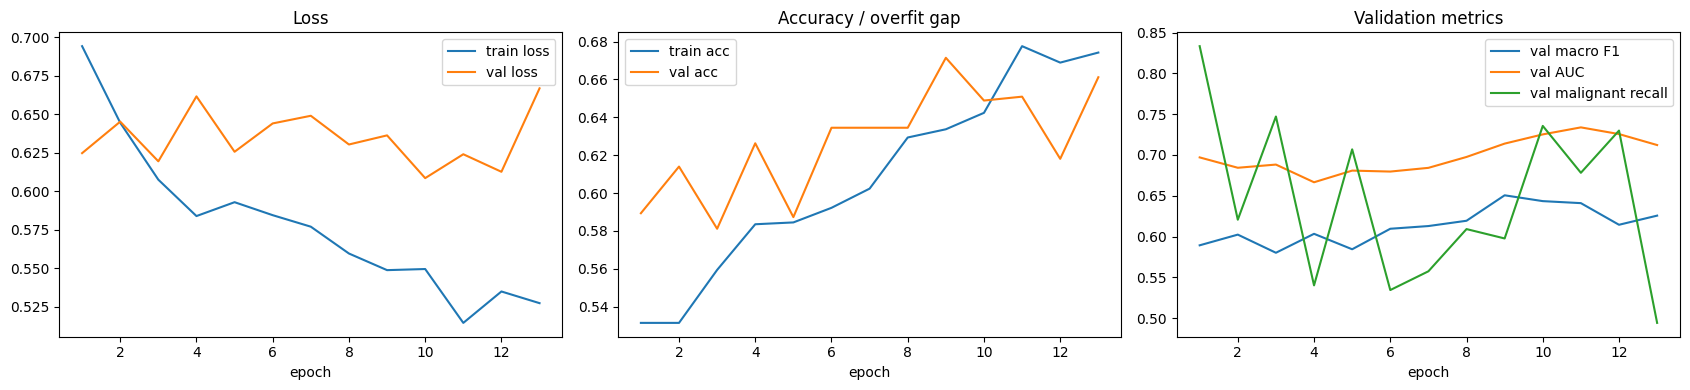

In [15]:
h = classifier.history

fig, ax = plt.subplots(1, 3, figsize=(17, 4))

ax[0].plot(h["epoch"], h["train_loss"], label="train loss")
ax[0].plot(h["epoch"], h["loss"], label="val loss")
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(h["epoch"], h["train_acc"], label="train acc")
ax[1].plot(h["epoch"], h["acc"], label="val acc")
ax[1].set_title("Accuracy / overfit gap")
ax[1].set_xlabel("epoch")
ax[1].legend()

ax[2].plot(h["epoch"], h["macro_f1"], label="val macro F1")
ax[2].plot(h["epoch"], h["auc"], label="val AUC")
ax[2].plot(h["epoch"], h["recall"], label="val malignant recall")
ax[2].set_title("Validation metrics")
ax[2].set_xlabel("epoch")
ax[2].legend()

plt.tight_layout()
plt.show()


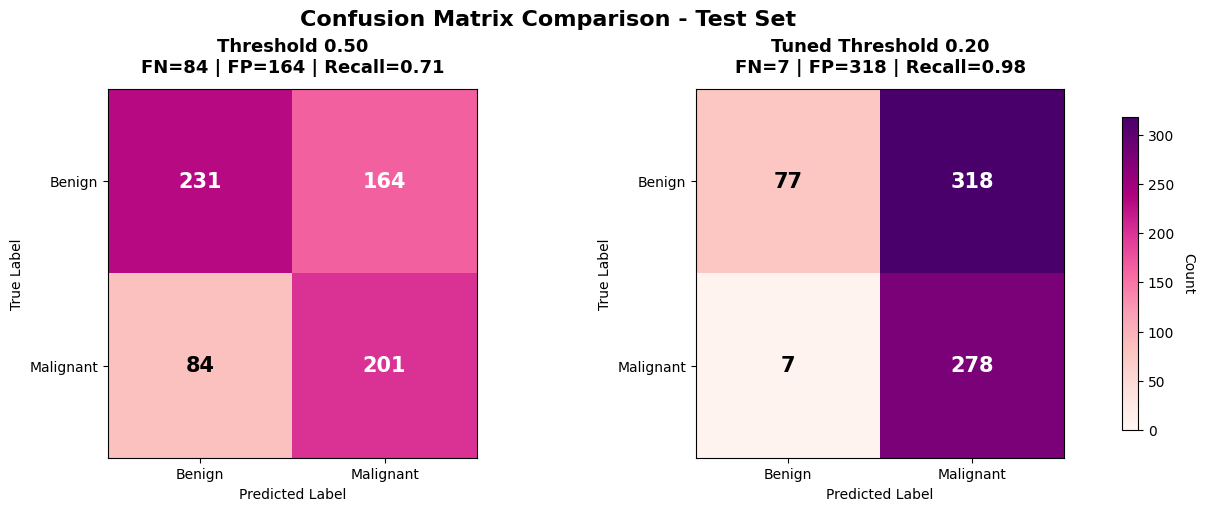

In [16]:
def get_cm_stats(cm):
    TN, FP, FN, TP = cm.ravel()
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    return TN, FP, FN, TP, recall, specificity

def plot_two_confusion_matrices(y_true, y_prob, tuned_threshold):
    # If probabilities are two columns, take malignant probability
    if len(y_prob.shape) == 2:
        malignant_prob = y_prob[:, 1]
    else:
        malignant_prob = y_prob

    thresholds = [0.50, tuned_threshold]
    titles = [
        "Threshold 0.50",
        f"Tuned Threshold {tuned_threshold:.2f}"
    ]

    cms = []
    stats = []

    for th in thresholds:
        y_pred = (malignant_prob >= th).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        cms.append(cm)
        stats.append(get_cm_stats(cm))

    vmax = max(cm.max() for cm in cms)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    for ax, cm, title, stat in zip(axes, cms, titles, stats):
        TN, FP, FN, TP, recall, specificity = stat

        im = ax.imshow(cm, cmap="RdPu", vmin=0, vmax=vmax)

        ax.set_title(
            f"{title}\nFN={FN} | FP={FP} | Recall={recall:.2f}",
            fontsize=13,
            fontweight="bold",
            pad=12
        )

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Benign", "Malignant"])
        ax.set_yticklabels(["Benign", "Malignant"])

        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

        threshold_color = vmax / 2

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                color = "white" if cm[i, j] > threshold_color else "black"
                ax.text(
                    j, i, cm[i, j],
                    ha="center",
                    va="center",
                    color=color,
                    fontsize=15,
                    fontweight="bold"
                )

    # One shared colorbar for both plots
    cbar = fig.colorbar(im, ax=axes, shrink=0.85)
    cbar.set_label("Count", rotation=270, labelpad=15)

    plt.suptitle(
        "Confusion Matrix Comparison - Test Set",
        fontsize=16,
        fontweight="bold"
    )

    plt.show()



y_true = np.array(test_m["y_true"])
y_prob = np.array(test_m["y_prob"])

best_threshold = thr["threshold"] if isinstance(thr, dict) else thr

plot_two_confusion_matrices(
    y_true=y_true,
    y_prob=y_prob,
    tuned_threshold=best_threshold
)

### 8.2 Segmentation Model


In [17]:
def build_segmenter():
    try:
        m = smp.Unet(encoder_name=SEG_ENCODER, encoder_weights=SEG_ENCODER_WEIGHTS,
                     in_channels=3, classes=1, activation=None)
    except Exception as e:
        print("noisy-student weights unavailable, falling back to imagenet:", e)
        m = smp.Unet(encoder_name=SEG_ENCODER, encoder_weights="imagenet",
                     in_channels=3, classes=1, activation=None)
    return m.to(DEVICE).to(memory_format=torch.channels_last)

dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()
def seg_criterion(logits, target):
    return dice_loss(logits, target) + 0.5 * bce_loss(logits, target)

def dice_iou(logits, target, thr=0.5):
    prob = torch.sigmoid(logits); pred = (prob > thr).float()
    inter = (pred * target).sum((1, 2, 3))
    union = pred.sum((1, 2, 3)) + target.sum((1, 2, 3))
    dice = ((2 * inter + 1e-6) / (union + 1e-6))
    iou = ((inter + 1e-6) / (union - inter + 1e-6))
    return dice.sum().item(), iou.sum().item()

@torch.no_grad()
def evaluate_seg(model, loader):
    model.eval(); d_sum, i_sum, n = 0.0, 0.0, 0
    for x, m in loader:
        x = x.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
        m = m.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(x)
        d, i = dice_iou(logits.float(), m)
        d_sum += d; i_sum += i; n += x.size(0)
    return {"dice": d_sum / n, "iou": i_sum / n}

In [18]:
seg_loader_kw = {
    "num_workers": 0,
    "pin_memory": False
}

seg_train_loader = DataLoader(
    SegDataset(train_df, seg_train_tf),
    batch_size=SEG_BATCH,
    shuffle=True,
    drop_last=True,
    **seg_loader_kw
)

seg_val_loader = DataLoader(
    SegDataset(val_df, eval_tf),
    batch_size=SEG_BATCH,
    shuffle=False,
    drop_last=False,
    **seg_loader_kw
)

seg_test_loader = DataLoader(
    SegDataset(test_df, eval_tf),
    batch_size=SEG_BATCH,
    shuffle=False,
    drop_last=False,
    **seg_loader_kw
)

print("Segmentation loaders rebuilt successfully.")
print("Train batches:", len(seg_train_loader))
print("Val batches:", len(seg_val_loader))
print("Test batches:", len(seg_test_loader))

# Quick test: load one batch
x, m = next(iter(seg_train_loader))
print("Image batch shape:", x.shape)
print("Mask batch shape:", m.shape)
print("Image dtype:", x.dtype)
print("Mask dtype:", m.dtype)

Segmentation loaders rebuilt successfully.
Train batches: 259
Val batches: 61
Test batches: 85
Image batch shape: torch.Size([8, 3, 384, 384])
Mask batch shape: torch.Size([8, 1, 384, 384])
Image dtype: torch.float32
Mask dtype: torch.float32


In [19]:
def train_segmenter():
    seed_everything(SEED)
    model = build_segmenter()
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    enc = list(model.encoder.parameters())
    dec = list(model.decoder.parameters()) + list(model.segmentation_head.parameters())
    opt = optim.AdamW([{"params": enc, "lr": SEG_ENC_LR}, {"params": dec, "lr": SEG_DEC_LR}], weight_decay=1e-4)
    steps = len(seg_train_loader)
    sch = optim.lr_scheduler.OneCycleLR(opt, max_lr=[SEG_ENC_LR, SEG_DEC_LR],
                                        epochs=SEG_EPOCHS, steps_per_epoch=steps,
                                        pct_start=0.2, div_factor=10, final_div_factor=100)
    best, no_imp, history = -1.0, 0, []
    print("=" * 60, "\nSegmentation training\n", "=" * 60)
    for ep in range(SEG_EPOCHS):
        model.train(); tot, n = 0.0, 0
        for x, m in seg_train_loader:
            x = x.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
            m = m.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
                logits = model(x); loss = seg_criterion(logits, m)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sch.step()
            tot += loss.item() * x.size(0); n += x.size(0)
        vm = evaluate_seg(model, seg_val_loader)
        history.append({"epoch": ep + 1, "train_loss": tot / n, **vm})
        if vm["dice"] > best:
            best, no_imp = vm["dice"], 0
            torch.save({"model_state_dict": model.state_dict(), "encoder": SEG_ENCODER, "best_dice": float(best)}, SEG_CKPT)
            print("--> saved best")
        else:
            no_imp += 1
        print(f"[{ep+1}/{SEG_EPOCHS}] loss {tot/n:.4f} | val Dice {vm['dice']:.4f} IoU {vm['iou']:.4f}")
        if no_imp >= SEG_PATIENCE:
            print("Early stopping."); break

    ckpt = torch.load(SEG_CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.history = pd.DataFrame(history)
    print("Loaded best segmenter | val Dice", round(best, 4))
    return model

segmenter = train_segmenter()

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Segmentation training
--> saved best
[1/35] loss 0.5373 | val Dice 0.8643 IoU 0.7664
--> saved best
[2/35] loss 0.2583 | val Dice 0.8783 IoU 0.7880
--> saved best
[3/35] loss 0.2247 | val Dice 0.8825 IoU 0.7948
--> saved best
[4/35] loss 0.2082 | val Dice 0.8873 IoU 0.8023
--> saved best
[5/35] loss 0.2005 | val Dice 0.8891 IoU 0.8047
[6/35] loss 0.1938 | val Dice 0.8879 IoU 0.8029
--> saved best
[7/35] loss 0.1883 | val Dice 0.8945 IoU 0.8141
--> saved best
[8/35] loss 0.1801 | val Dice 0.8978 IoU 0.8188
[9/35] loss 0.1745 | val Dice 0.8967 IoU 0.8170
--> saved best
[10/35] loss 0.1669 | val Dice 0.8981 IoU 0.8192
--> saved best
[11/35] loss 0.1606 | val Dice 0.8986 IoU 0.8203
[12/35] loss 0.1570 | val Dice 0.8970 IoU 0.8180
[13/35] loss 0.1509 | val Dice 0.8985 IoU 0.8201
--> saved best
[14/35] loss 0.1455 | val Dice 0.9003 IoU 0.8227
[15/35] loss 0.1414 | val Dice 0.8999 IoU 0.8225
[16/35] loss 0.1346 | val Dice 0.8993 IoU 0.8215
[17/35] loss 0.1304 | val Dice 0.8994 IoU 0.8214
[18/

#### 8.2.1 Evaluate and visualization

TEST Dice: 0.8790   IoU: 0.8000


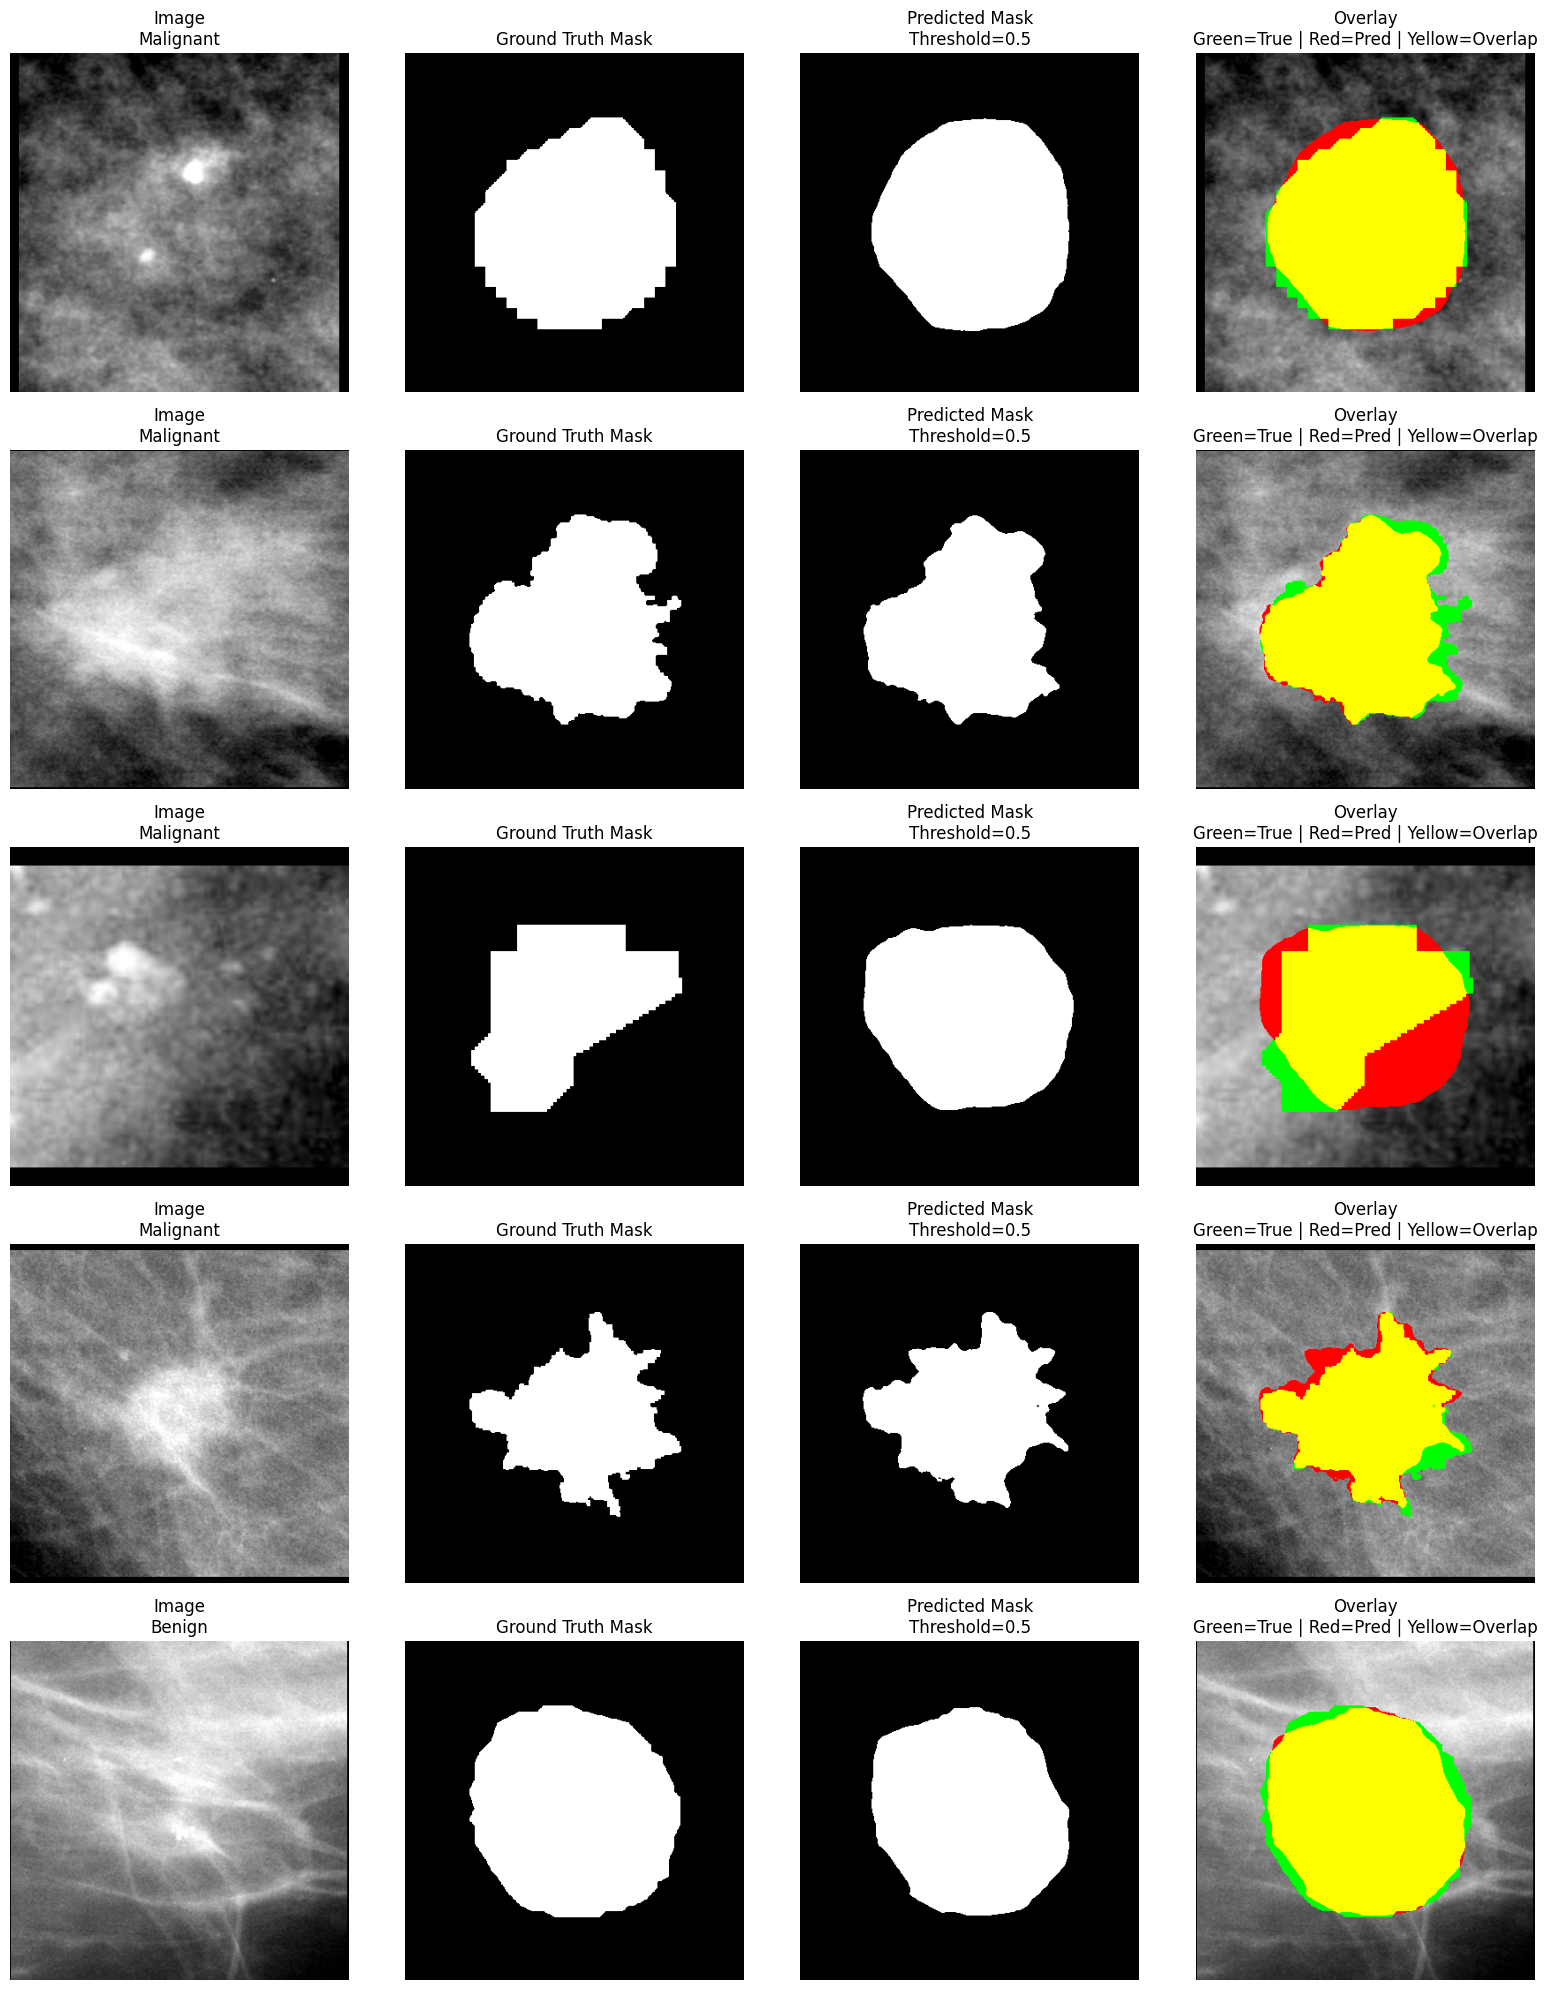

In [20]:
seg_test = evaluate_seg(segmenter, seg_test_loader)
print(f"TEST Dice: {seg_test['dice']:.4f}   IoU: {seg_test['iou']:.4f}")

SEG_THRESHOLD = 0.5

segmenter.eval()

rows = test_df.sample(5, random_state=7).reset_index(drop=True)

fig, axes = plt.subplots(len(rows), 4, figsize=(16, 4 * len(rows)))

if len(rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, (_, r) in enumerate(rows.iterrows()):
    img = load_rgb(r["img_crop_path"])

    gt = cv2.imread(r["mask_crop_path"], cv2.IMREAD_GRAYSCALE)
    gt = (gt > 127).astype(np.uint8)

    x = eval_tf(image=img)["image"].unsqueeze(0).to(DEVICE)
    x = x.to(memory_format=torch.channels_last)

    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
        prob = torch.sigmoid(segmenter(x))[0, 0].float().cpu().numpy()
        pred = (prob > SEG_THRESHOLD).astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Make RGB overlay
    base = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    overlay = base.copy()

    gt_mask = gt > 0
    pred_mask = pred > 0
    overlap = gt_mask & pred_mask

    # Red = prediction
    overlay[pred_mask] = [255, 0, 0]

    # Green = ground truth
    overlay[gt_mask] = [0, 255, 0]

    # Yellow = overlap
    overlay[overlap] = [255, 255, 0]

    axes[i, 0].imshow(gray, cmap="gray")
    axes[i, 0].set_title(f"Image\n{r['label_name']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred, cmap="gray")
    axes[i, 2].set_title(f"Predicted Mask\nThreshold={SEG_THRESHOLD}")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(overlay)
    axes[i, 3].set_title("Overlay\nGreen=True | Red=Pred | Yellow=Overlap")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

### 8.3. Explainable AI: Grad-CAM++



In [21]:
def find_last_conv(module):
    last_name, last = None, None
    for name, m in module.named_modules():
        if isinstance(m, nn.Conv2d):
            last_name, last = name, m
    return last_name, last

cam_layer_name, cam_layer = find_last_conv(classifier.backbone)
print("Grad-CAM++ target layer:", cam_layer_name)

class GradCAMpp:
    def __init__(self, model, target_layer):
        self.model = model; self.acts = None; self.grads = None
        self.fh = target_layer.register_forward_hook(self._fh)
        self.bh = target_layer.register_full_backward_hook(self._bh)
    def _fh(self, m, i, o): self.acts = o
    def _bh(self, m, gi, go): self.grads = go[0]
    def remove(self): self.fh.remove(); self.bh.remove()
    def __call__(self, x, class_idx=1):
        self.model.eval(); self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        score = logits[:, class_idx].sum()
        score.backward()
        g = self.grads; a = self.acts
        g2, g3 = g.pow(2), g.pow(3)
        sa = a.sum(dim=(2, 3), keepdim=True)
        denom = 2 * g2 + sa * g3
        denom = torch.where(denom != 0, denom, torch.ones_like(denom))
        alpha = g2 / denom
        weights = (alpha * torch.relu(g)).sum(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * a).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        probs = torch.softmax(logits, 1).detach().cpu().numpy()[0]
        return cam, probs

def cam_for_row(row, class_idx=1):
    img = load_rgb(row["img_crop_path"])
    x = eval_tf(image=img)["image"].unsqueeze(0).to(DEVICE).to(memory_format=torch.channels_last)
    engine = GradCAMpp(classifier, cam_layer)
    cam, probs = engine(x, class_idx)
    engine.remove()
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), cam, probs

Grad-CAM++ target layer: conv_head


In [22]:
def show_cam(row, title_prefix):
    gray, cam, probs = cam_for_row(row, class_idx=1)
    gt = (cv2.imread(row["mask_crop_path"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    pred = int(probs.argmax())
    fig, ax = plt.subplots(1, 3, figsize=(13, 4.3))
    ax[0].imshow(gray, cmap="gray")
    cnts, _ = cv2.findContours(gt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    g3 = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB); cv2.drawContours(g3, cnts, -1, (0, 255, 0), 2)
    ax[0].imshow(g3); ax[0].set_title("Image + GT mask (green)"); ax[0].axis("off")
    ax[1].imshow(cam, cmap="jet"); ax[1].set_title("Grad-CAM++"); ax[1].axis("off")
    ax[2].imshow(gray, cmap="gray"); ax[2].imshow(cam, cmap="jet", alpha=0.40)
    ax[2].set_title(f"{title_prefix}\nTrue {row['label_name']} | Pred {label_names[pred]} | P(mal) {probs[1]:.2f}")
    ax[2].axis("off")
    plt.tight_layout(); plt.show()

# attach predictions to test_df for case selection
test_df = test_df.copy()
test_df["pred"] = (test_m["y_prob"][:, 1] >= thr["threshold"]).astype(int)
test_df["p_mal"] = test_m["y_prob"][:, 1]

print(">>> Correctly detected malignant cases")
for _, r in test_df[(test_df.label == 1) & (test_df.pred == 1)].head(3).iterrows():
    show_cam(r, "Correct malignant")

print(">>> False negatives (malignant predicted benign)")
fns = test_df[(test_df.label == 1) & (test_df.pred == 0)]
for _, r in fns.head(3).iterrows():
    show_cam(r, "False negative")

Output hidden; open in https://colab.research.google.com to view.

In [23]:
# Quantitative XAI: mean IoU between Grad-CAM++ and the ground-truth mask (malignant test set)
def cam_iou(row, cam_thr=0.5, class_idx=1):
    _, cam, _ = cam_for_row(row, class_idx)
    gt = (cv2.imread(row["mask_crop_path"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
    cb = (cam >= cam_thr).astype(np.uint8)
    inter = int((cb & gt).sum()); union = int((cb | gt).sum())
    return inter / (union + 1e-8)

mal_test = test_df[test_df.label == 1]
ious = [cam_iou(r) for _, r in tqdm(mal_test.iterrows(), total=len(mal_test), desc="CAM-IoU")]
print(f"\nGrad-CAM++ vs GT mask  |  malignant test cases: {len(ious)}")
print(f"Mean IoU:   {np.mean(ious):.4f}")
print(f"Median IoU: {np.median(ious):.4f}")
print(f"% cases IoU>0.10: {100*np.mean(np.array(ious)>0.10):.1f}%   IoU>0.25: {100*np.mean(np.array(ious)>0.25):.1f}%")

CAM-IoU:   0%|          | 0/285 [00:00<?, ?it/s]


Grad-CAM++ vs GT mask  |  malignant test cases: 285
Mean IoU:   0.5234
Median IoU: 0.5250
% cases IoU>0.10: 100.0%   IoU>0.25: 97.5%


## 9. Save trained Models


In [24]:
seg_test = evaluate_seg(segmenter, seg_test_loader)

bundle = {
    "classifier_state_dict": classifier.state_dict(),
    "segmenter_state_dict": segmenter.state_dict(),

    "cls_encoder": CLS_ENCODER,
    "seg_encoder": SEG_ENCODER,
    "seg_encoder_weights": SEG_ENCODER_WEIGHTS,

    "image_size": IMAGE_SIZE,
    "label_names": label_names,
    "threshold": float(thr["threshold"]),
    "context_crop_ratio": float(CONTEXT),

    "preprocessing": {
        "mean": MEAN,
        "std": STD,
        "input_channels": 3,
        "image_mode": "grayscale_converted_to_rgb",
        "normalization": "ImageNet mean/std",
        "resize_method": "resize_pad_to_square",
    },

    "test_metrics": {
        "cls_auc": float(m_default["auc"]),
        "cls_macro_f1_default": float(m_default["macro_f1"]),
        "cls_balanced_acc_default": float(m_default["bal_acc"]),

        "cls_tuned_recall": float(m_tuned["recall"]),
        "cls_tuned_specificity": float(m_tuned["specificity"]),
        "cls_tuned_FN": int(m_tuned["FN"]),
        "cls_tuned_FP": int(m_tuned["FP"]),
        "cls_tuned_cost": int(m_tuned["cost"]),

        "seg_dice": float(seg_test["dice"]),
        "seg_iou": float(seg_test["iou"]),

        "cam_mean_iou": float(np.mean(ious)),
        "cam_median_iou": float(np.median(ious)),
        "cam_iou_gt_010_percent": float(np.mean(np.array(ious) > 0.10) * 100),
        "cam_iou_gt_025_percent": float(np.mean(np.array(ious) > 0.25) * 100),
    },

    "training_notes": {
        "classification_strategy": (
            "Image-only classifier trained on lesion crops. "
            "Uses cost-sensitive CrossEntropy, malignant class multiplier, "
            "partial backbone fine-tuning, and recall-based threshold tuning."
        ),
        "segmentation_strategy": (
            "U-Net segmentation model trained on aligned lesion crops and ground-truth ROI masks."
        ),
        "xai_strategy": (
            "Grad-CAM++ heatmaps generated from the classifier and evaluated against "
            "ground-truth lesion masks using CAM-IoU."
        ),
        "overfit_control": (
            "Dropout, label smoothing, weight decay, moderate augmentation, "
            "early stopping, and train/validation gap monitoring."
        ),
        "roi_caveat": (
            "Training crops are generated using ground-truth ROI masks. "
            "For production/API, replace this with predicted segmentation/detection "
            "or retrain the model on the same type of images expected by the API."
        ),
    },

    "deployment_notes": {
        "training_roi_source": "ground_truth_roi_mask",
        "recommended_api_roi_source": "segmentation_predicted_mask",
        "fallback_roi_source": "center_crop_fallback",
        "recommended_api_flow": [
            "user_uploads_mammogram",
            "segmenter_predicts_lesion_mask",
            "largest_mask_component_is_used_to_create_roi_crop",
            "classifier_predicts_benign_or_malignant_on_roi_crop",
            "gradcamplusplus_generates_xai_heatmap_on_same_roi_crop",
            "api_returns_prediction_confidence_segmentation_and_xai"
        ],
        "roi_warning": (
            "This model was trained on lesion crops generated from ground-truth ROI masks. "
            "For production, use the segmentation model to predict the lesion mask, "
            "crop the ROI from that predicted mask, then run classification and XAI "
            "on the same ROI. If center_crop_fallback is used, classification reliability "
            "may be lower because the input distribution differs from training."
        ),
    },
}

torch.save(bundle, "MedGuard_multitask_bundle_v1.pth")

summary = {
    "cls_encoder": CLS_ENCODER,
    "seg_encoder": SEG_ENCODER,
    "image_size": IMAGE_SIZE,
    "label_names": label_names,
    "threshold": float(thr["threshold"]),
    "context_crop_ratio": float(CONTEXT),
    "test_metrics": bundle["test_metrics"],
    "deployment_notes": bundle["deployment_notes"],
}

with open("MedGuard_summary_v1.json", "w") as f:
    json.dump(summary, f, indent=2)

files = [
    "MedGuard_multitask_bundle_v1.pth",
    "MedGuard_summary_v1.json",
    CLS_CKPT,
    SEG_CKPT,
]

with zipfile.ZipFile("Medguard_package_v1.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    for fn in files:
        if os.path.exists(fn):
            zf.write(fn)

print("Saved all bundle, summary, and package.")
print(json.dumps(summary, indent=2))

Saved all bundle, summary, and package.
{
  "cls_encoder": "tf_efficientnetv2_s.in21k_ft_in1k",
  "seg_encoder": "timm-efficientnet-b3",
  "image_size": 384,
  "label_names": [
    "Benign",
    "Malignant"
  ],
  "threshold": 0.2,
  "context_crop_ratio": 0.6,
  "test_metrics": {
    "cls_auc": 0.7138663113479902,
    "cls_macro_f1_default": 0.6345828819068255,
    "cls_balanced_acc_default": 0.6450366422385077,
    "cls_tuned_recall": 0.9754385964570021,
    "cls_tuned_specificity": 0.19493670885582437,
    "cls_tuned_FN": 7,
    "cls_tuned_FP": 318,
    "cls_tuned_cost": 101800,
    "seg_dice": 0.878610378854415,
    "seg_iou": 0.7997250669142779,
    "cam_mean_iou": 0.5234129889053165,
    "cam_median_iou": 0.5249929325896212,
    "cam_iou_gt_010_percent": 100.0,
    "cam_iou_gt_025_percent": 97.54385964912281
  },
  "deployment_notes": {
    "training_roi_source": "ground_truth_roi_mask",
    "recommended_api_roi_source": "segmentation_predicted_mask",
    "fallback_roi_source": "c